In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [3]:
print("🔎 Datasetning dastlabki 5 qatori:")
df.head()

🔎 Datasetning dastlabki 5 qatori:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
filtered_df = df[df['target'].isin([0,1])].copy()

In [5]:
X = filtered_df.drop('target', axis=1)
y = filtered_df['target']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [9]:
y_pred = svm_model.predict(X_test_scaled)

In [10]:
print("\n📊 Klassifikatsiya hisoboti:")
print(classification_report(y_test, y_pred))


📊 Klassifikatsiya hisoboti:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [11]:
print("\n📉 Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


📉 Confusion matrix:
[[15  0]
 [ 0 15]]


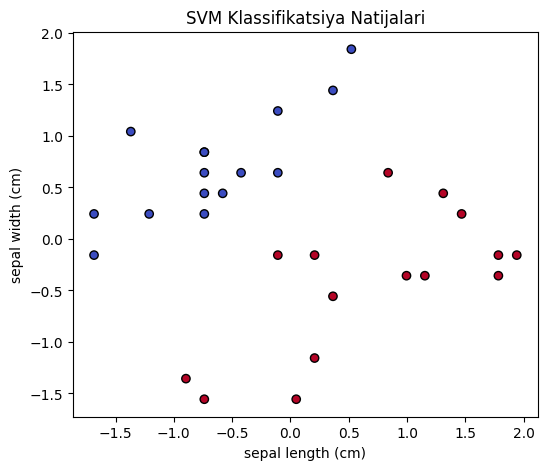

In [12]:
plt.figure(figsize=(6,5))
plt.scatter(X_test_scaled[:,0], X_test_scaled[:,1], c=y_pred, cmap='coolwarm', edgecolors='k')
plt.title("SVM Klassifikatsiya Natijalari")
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.show()